## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nathan Brence

**Date:** 10/2/2026

### Question 1

1. Classification is a statistical method that predicts class or category, while regression involves predicting a numerical outcome
2. A confusion table is a matrix that counts and sorts observations based on their actual class and predicted class. It's useful for understanding a model's performance because it provides context into its accuracy, revealing which classes are predicted correctly and which are often mistaken for other categories. 
3. The SSE (Sum of Squared Errors) of a model, in the most literal definition, calculates the sum of the squared distances (or residuals) of each datapoint from a model's regression line. Essentially, SSE quantifies the prediction error in a linear model. 
4. Overfitting and underfitting can be thought of as two sides of the same coin, and that coin is predictive models that fail to reflect tangible patterns in data. Regarding the KNN algorithm, using a very small k-value may result in overfitting, in which the model incorporates noise into its predictions rather than actual patterns in the data. Comversely, an excessively large k-value could lead to underfitting, where the model considers so many neighboring data points that it generates nearly identical predictions for each observation.
5. Splitting the data and choosing k based on evaluation of error metrics on the test dataset improves model performance by increasing a model's generalization, or ability to perform prediction on data it wasn't trained on. Using the training dataset to configure the model and running an algorithm to find k in relation to SSE or accuracy score on the test dataset (which, in this case, is unforeseen data), one can create a model that has the best chances of being applicable to new sources of data in practice.
6. Using a class label as a prediction is effective because it's much easier to interpret and implement into practice due to its simplicity, but it also possesses the weakness of ignoring confidence of each prediction into the model. In other words, a class label with 50.1% confidence is treated the same as one with 100% confidence, throwing away nuanced data patterns in favor of simplicity. A probability distribution of class labels, however, preserves this uncertainty and allows for a more robust perspective of a model's classification. The downside to this is that such a method is difficult to implement into practice, with the additional weakness of poor interpretation stemming from its complexity.

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 
Missing Values: 0

count    338.000000
mean       0.503550
std        0.344244
min        0.000000
25%        0.200000
50%        0.600000
75%        0.800000
max        1.000000
Name: soil, dtype: float64 
Missing Values: 0

count    338.000000
mean       0.430634
std        0.195819
min        0.197734
25%        0.309737
50%        0.359516
75%        0.482628
max        0.999999
Name: voltage, dtype: float64 
Missing Values: 0

count    338.000000
mean       0.508876
std        0.306043
min        0.000000
25%        0.272727
50%        0.545455
75%        0.727273
max        1.000000
Name: height, dtype: float64 
Missing Values: 0



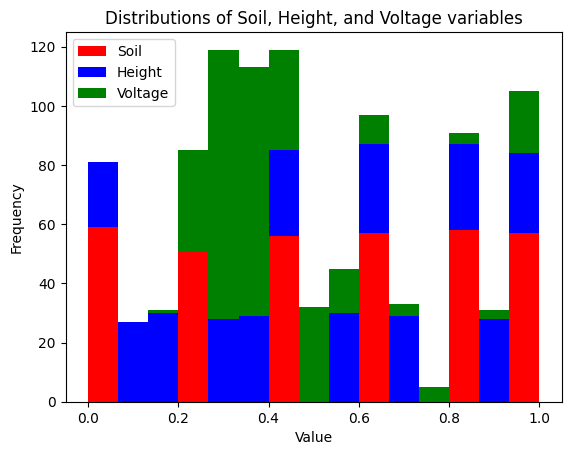

In [50]:
# Question 2
# Part 1

#import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from matplotlib import pyplot as plt

#load csv into mines variable
mines = pd.read_csv("land_mines.csv")

#summarize type variable using value_counts()
m_type = mines["mine_type"].value_counts()

#obtain info on numerical variables using describe()
soil = mines["soil"].describe()
volt = mines["voltage"].describe()
height = mines["height"].describe()

#print each summarization and amount of missing values
print(m_type, "\nMissing Values: " + str(mines["mine_type"].isna().sum())+ "\n")
print(soil, "\nMissing Values: " + str(mines["soil"].isna().sum()) + "\n")
print(volt, "\nMissing Values: " + str(mines["voltage"].isna().sum()) + "\n")
print(height, "\nMissing Values: " + str(mines["height"].isna().sum()) + "\n")

#create stacked histogram of numerical variables to compare distributions
plt.hist([mines["soil"], mines["height"], mines["voltage"]], bins=15, stacked=True, color=["red", "blue", "green"], label=["Soil", "Height", "Voltage"])
plt.title("Distributions of Soil, Height, and Voltage variables")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()

In [45]:
# Question 2
# Part 2

#Define x and y values based on above description, then split 50/50 with test_size=0.5
x_vals = mines[["voltage", "height", "soil"]]
y_vals = mines["mine_type"]
x_train, x_test, y_train, y_test = train_test_split(x_vals, y_vals, test_size=0.5, random_state=26)

#We can observe from the above attribute summaries that they're all already between 0 and 1, so no scaling is necessary


In [46]:
# Question 2
# Part 3

#utilize following algorithm to find k value that maximizes the accuracy of the test dataset (k_star): Returns 3
#use range of 1 to 10 for k candidates to ensure small dataset isn't underfit

k_vals = np.arange(1, 11)
test_acc = []
for k in k_vals:
    k_candidate = KNeighborsClassifier(n_neighbors=int(k))
    k_candidate.fit(x_train, y_train)
    test_hat = k_candidate.predict(x_test)
    test_acc.append(accuracy_score(y_test, test_hat))
k_star = int(k_vals[np.argmax(test_acc)])
print(f"Optimal k-value = {k_star}")

#create the kNN classifier utilizing the k_star value for k, generating predicted values from test data
model = KNeighborsClassifier(n_neighbors=k_star).fit(x_train, y_train)
y_pred = model.predict(x_test)

Optimal k-value = 3


As mentioned above, I used an algorithm to find the k-value that maximizes the accuracy score of the test dataset, utilizing only a small range of 1 to 10 for k-value candidates to avoid underfitting the model.

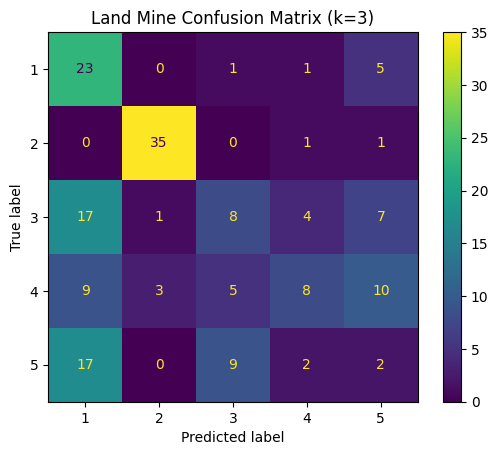

In [ ]:
# Question 2
# Part 4
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])
display.plot()
plt.title("Land Mine Confusion Matrix (k=3)")
plt.show()

According to the confusion matrix, the model is accurate in many respects, predicting type 1 and 2 mines to an extremely precise extent as evident by the low number of false negatives. On the other hand, the other three categories (3, 4, and 5) have serious flaws in accuracy with this model, with many of them being marked as being within the type 1 category and each having less than 10 (out of ~50 each) being predicted correctly.

### Question 2, Part 5
With reference to the above confusion matrix, the only category of mine that can be consistently predicted correctly is type 2. This is because type 2 is the only category with a small number of false positive (observation is not type 2, but predicted as such) and false negative predictions (observation is type 2, but not predicted as such). Some categories, such as type 1, have too many false positives for the model to be applied unquestionably in practice. Other classes, like types 3, 4, and 5, produce generally inaccurate predictions since the model's predictions result in a high quantity of false positives and false negatives within these categories. Hence, my advice to anyone applying this model to a real-world minefield would be to trust the model when it predicts a mine is type 2, but do not take any other class prediction at face value and perform additional research to confirm the category of mine.  

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 49a768bebcd75e58ea9d190db35bb2ccc5191ba0
- **AI tool and model used:** Claude

### *Prompts used

1. Given the listed questions and answers for part 1 of this assignment, make a series of suggestions on what can be improved about each of these responses. Provide a numbered list summarizing the recommendations at the bottom:

Questions:
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Answers:
1. Classification is a statistical method that predicts class or category, while regression involves predicting a numerical outcome
2. A confusion table is a matrix that counts and sorts observations based on their actual class and predicted class. It's useful for understanding a model's performance because it provides context into its accuracy, revealing which classes are predicted correctly and which are often mistaken for other categories.
3. The SSE (Sum of Squared Errors) of a model, in the most literal definition, calculates the sum of the squared distances (or residuals) of each datapoint from a model's regression line. Essentially, SSE quantifies the prediction error in a linear model.
4. Overfitting and underfitting can be thought of as two sides of the same coin, and that coin is predictive models that fail to reflect tangible patterns in data. Regarding the KNN algorithm, using a very small k-value may result in overfitting, in which the model incorporates noise into its predictions rather than actual patterns in the data. Comversely, an excessively large k-value could lead to underfitting, where the model considers so many neighboring data points that it generates nearly identical predictions for each observation.
5. Splitting the data and choosing k based on evaluation of error metrics on the test dataset improves model performance by increasing a model's generalization, or ability to perform prediction on data it wasn't trained on. Using the training dataset to configure the model and running an algorithm to find k in relation to SSE or accuracy score on the test dataset (which, in this case, is unforeseen data), one can create a model that has the best chances of being applicable to new sources of data in practice.
6. Using a class label as a prediction is effective because it's much easier to interpret and implement into practice due to its simplicity, but it also possesses the weakness of ignoring confidence of each prediction into the model. In other words, a class label with 50.1% confidence is treated the same as one with 100% confidence, throwing away nuanced data patterns in favor of simplicity. A probability distribution of class labels, however, preserves this uncertainty and allows for a more robust persepective of a model's classification. The downside to this is that such a method is difficult to implement into practice, with the additional weakness of poor interpretation stemming from its complexity.


2. Given the listed questions and answers for part 2 of this assignment, make a series of suggestions on what can be improved about each of these responses. Provide a numbered list summarizing the recommendations at the bottom:

Questions:
1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Answers:

#Question 2
#Part 1

#import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from matplotlib import pyplot as plt

#load csv into mines variable
mines = pd.read_csv("land_mines.csv")

#summarize type variable using value_counts()
m_type = mines["mine_type"].value_counts()

#obtain info on numerical variables using describe()
soil = mines["soil"].describe()
volt = mines["voltage"].describe()
height = mines["height"].describe()

#print each summarization and amount of missing values
print(m_type, "\nMissing Values: " + str(mines["mine_type"].isna().sum())+ "\n")
print(soil, "\nMissing Values: " + str(mines["soil"].isna().sum()) + "\n")
print(volt, "\nMissing Values: " + str(mines["voltage"].isna().sum()) + "\n")
print(height, "\nMissing Values: " + str(mines["height"].isna().sum()) + "\n")

#create stacked histogram of numerical variables to compare distributions
plt.hist([mines["soil"], mines["height"], mines["voltage"]], bins=15, stacked=True, color=["red", "blue", "green"], label=["Soil", "Height", "Voltage"])
plt.title("Distributions of Soil, Height, and Voltage variables")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()

#Question 2
#Part 2

#Define x and y values based on above description, then split 50/50 with test_size=0.5
x_vals = mines[["voltage", "height", "soil"]]
y_vals = mines["mine_type"]
x_train, x_test, y_train, y_test = train_test_split(x_vals, y_vals, test_size=0.5, random_state=26)

#We can observe from the above attrbite summaries that they're all already between 0 and 1, so no scaling is necessary

#Question 2
#Part 3

#utilize following algorithm to find k value that maximizes the accuracy of the test dataset (k_star): Returns 3
#use range of 1 to 10 for k candidates to ensure small dataset isn't underfit

k_vals = np.arange(1, 11)
test_acc = []
for k in k_vals:
    k_candidate = KNeighborsClassifier(n_neighbors=int(k))
    k_candidate.fit(x_train, y_train)
    test_hat = k_candidate.predict(x_test)
    test_acc.append(accuracy_score(y_test, test_hat))
k_star = int(k_vals[np.argmax(test_acc)])
print(f"Optimal k-value = {k_star}")

#create the kNN classifier utilizing the k_star value for k, generating predicted values from test data
model = KNeighborsClassifier(n_neighbors=k_star).fit(x_train, y_train)
y_pred = model.predict(x_test)

#create the kNN classifier utilizing the k_star value for k, generating predicted values from test data
model = KNeighborsClassifier(n_neighbors=k_star).fit(x_train, y_train)
y_pred = model.predict(x_test)

As mentioned above, I used an algorithm to find the k-value that maximizes the accuracy score of the test dataset, utilizing only a small range of 1 to 10 for k-value candidates to avoid underfitting the model.

#Question 2
#Part 4
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])
display.plot()
plt.title("Land Mine Confusion Matrix (k=3)")
plt.show()

According to the confusion matrix, the model is accurate in many respects, predicting type 1 and 2 mines to an extremely precise extent as evident by the low number of false negatives. On the other hand, the other three categories (3, 4, and 5) have serious flaws in accuracy with this model, with many of them being marked as being within the type 1 category and each having less than 10 (out of ~50 each) being predicted correctly.

Question 2, Part 5:
With reference to the above confusion matrix, the only category of mine that can be consistently predicted correctly is type 2. This is because type 2 is the only category with a small number of false positive (observation is not type 2, but predicted as such) and false negative predictions (observation is type 2, but not predicted as such). Some categories, such as type 1, have too many false positives for the model to be applied unquestionably in practice. Other classes, like types 3, 4, and 5, produce generally inaccurate predictions since the model's predictions result in a high quantity of false positives and false negatives within these categories. Hence, my advice to anyone applying this model to a real-world minefield would be to trust the model when it predicts a mine is type 2, but do not take any other class prediction at face value and perform additional research to confirm the category of mine.

### *AI-proposed changes


1. 
    1. Describe the confusion table's layout and error types, and explain how it exposes what overall accuracy hides.
    2. Give the SSE formula, explain squaring, and drop the "linear model only" framing.
    3. Rewrite Q4's opening and define over/underfitting generally (training vs. test error, flexibility) before applying them to k.
    4. Reframe Q5: splitting gives honest evaluation and lets you tune k, rather than "improving performance."
    5. In Q6, correct the claim that probabilities are hard to implement, and add thresholds, calibration, and coarse k-NN probabilities.
2. 
    1. Replace the stacked histogram with separate or overlaid plots, and add class proportions and a bar chart.
    2. Use stratify=y_vals, justify the 50/50 split, and verify the scaling claim with printed min/max.
    3. Print the overall accuracy and a classification_report with per-class precision and recall.
    4. Use exact counts, model.classes_ for labels, and an f-string for the title.
    5. Fix the precision/recall terminology and resolve the Q4–Q5 inconsistency about type 1.
    6. In Q5, center the advice on precision, quantify it, and add concrete steps (probability thresholds, verification protocol, more data/features, validation on new data). 

### *Evaluation of AI suggestions


### Question 1

| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / **modify** / reject | Explaining the structure and error types of a confusion table would be helpful to fleshing out my explanation of them and implementing additional context. Howvever, my explanation already includes information regarding how confusion tables provide additional context to accuracy scores, so this portion is not needed. |
| 2 | Accept / **modify** / reject | Giving the entire SSE formula is redundant, as the description I gave already described the formula in plain words, with the mention of squaring being excessive given the bounds of the question. However, the suggestion is correct that SSE is not exclusively applicable to linear models, making this portion of the recommendation worth implementing. |
| 3 | Accept / **modify** / reject | After reviewing my phase 1 response to question four, I agree that including a more general definition of overfitting and underfitting would be useful for showing general understanding. On the other hand, I'm in favor of keeping my opening sentence, since it relates both concepts in an intuitive way. |
| 4 | Accept / modify / **reject** | Both of these attributes of data splitting and picking k based on model accuracy are already mentioned in my phase 1 answer. In addition, the wording of the question explicitly asks to connect these methods to "improved model performance", making the second portion of the criticism irrelevant. |
| 5 | Accept / **modify** / reject | A majority of the concepts mentioned in this suggestion (i.e. calibration and coarse probabilites) were not explictly discussed in either this assignment or any class lecture, so it would be irrelevant to include such information. However, after verifying through additional research on probability distributions with class labels, I was indeed incorrect that it was difficult to implement, which will be changed in the phase 2 response. |

### Question 2

| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / **modify** / reject | Since the purpose of visualizing each of the numerical variables was to compare their distributions, the AI's criticism of the stacked bar chat not properly achieving this goal is correct. However, showing mine_type proportions in a bar chart is unnecessary, as the distribution can already be approxiamted through the value_counts() table present earlier in the output. |
| 2 | Accept / **modify** / reject | The use of the stratify keyword, as verified in a copy of this notebook, is necessary to ensure that the training and test datasets are randomly sampled. However, printing the minimum and maximum of each variable would be redundant since this was already performed in our EDA. Additionally, the question does not ask the 50/50 split to be justified, rather to simply implement it into our splitting. |
| 3 | Accept / modify / **reject** | Not only are neither of these accuracy metrics asked for in the question they allude to, but they are irrelevant to this assignment's prescribed process of evaluating our model. In other words, most of the quality judgments made about the model are done using the confusion matrix rather than the listed metrics of fit. |
| 4 | Accept / modify / **reject** | This suggestion was made with respect to the confusion matrix. All of the mentioned characteristics in the suggestion are present in the phase 1 confusion table, so this recommendation can be rejected. |
| 5 | Accept / **modify** / reject | The "precision/recall terminology" relates to how the terms refer to a model with a low number of false positives and false negatives respectively, implying that my use of "precise" to describe the model's lack of false negatives was incorrect. While this suggestion may be overly technical, I believe it's worth including since it's a small fix that greatly increases interpretation of my explanation. On the other hand, the "Q4-Q5 inconsistency" refers to how I praised the model for categorizing type 1 mines correctly in question four, but then explained how the high volume of type 1 false positives make such predictions unreliable. This isn't an inconsistency, however, as both statements are true and don't contradict each other. In this regard, no changes are necessary. |
| 6 | Accept / modify / **reject** | The recommendation of future steps to improve the model (as the suggestion makes) are not within the bounds of the question it refers to. Similarly, quantifying error is a bit overbearing for question that's worded to indicate that it wants application advice based off general trends present in the confusion table. For these reasons, the suggestion can be rejected. |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### QUESTION 1

1. Classification is a statistical method that predicts class or category, while regression involves predicting a numerical outcome
2. A confusion table is a matrix that counts and sorts observations based on their actual class and predicted class. The structure is a two-dimensional grid (with length and width depending on the number of classes), with one axis representing an observation's actual class and the other indicating its predicted category, guiding the sorting process. Through this structure, a confusion table can also indicate the number of false positives (observation predicted to be in target class, but is actually in another class) and false negatives (observation predicted to be in another class, but is actually in target class) associated with each class. It's useful for understanding a model's performance because it provides context into its accuracy, revealing which classes are predicted correctly and which are often mistaken for other categories. 
3. The SSE (Sum of Squared Errors) of a model, in the most literal definition, calculates the sum of the squared differences (or residuals) of each datapoint from a model's prediction of that datapoint. Essentially, SSE quantifies the prediction error in a model. 
4. Overfitting and underfitting can be thought of as two sides of the same coin, and that coin is predictive models that fail to reflect tangible patterns in data. In the case of overfitting, a model incorporates noise into its predictions in addition to actual patterns in the training data, which is typical the result of too many features being used for training. Conversely, underfitting is where a model doesn't consider enough features and can't adequately capture the insights from training. Both overfitting and underfitting result in models with low generalization and next to no practical use.
5. Splitting the data and choosing k based on evaluation of error metrics on the test dataset improves model performance by increasing a model's generalization, or ability to perform prediction on data it wasn't trained on. Using the training dataset to configure the model and running an algorithm to find k in relation to SSE or accuracy score on the test dataset (which, in this case, is unforeseen data), one can create a model that has the best chances of being applicable to new sources of data in practice.
6. Using a class label as a prediction is effective because it's much easier to interpret and implement into practice due to its simplicity, but it also possesses the weakness of ignoring confidence of each prediction into the model. In other words, a class label with 50.1% confidence is treated the same as one with 100% confidence, throwing away nuanced data patterns in favor of simplicity. A probability distribution of class labels, however, preserves this uncertainty and allows for a more robust perspective of a model's classification. The downside to this is that the complexity of the model results in a poor interpretability, which could negatively impact the using such a method in practice.

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 
Missing Values: 0

count    338.000000
mean       0.503550
std        0.344244
min        0.000000
25%        0.200000
50%        0.600000
75%        0.800000
max        1.000000
Name: soil, dtype: float64 
Missing Values: 0

count    338.000000
mean       0.430634
std        0.195819
min        0.197734
25%        0.309737
50%        0.359516
75%        0.482628
max        0.999999
Name: voltage, dtype: float64 
Missing Values: 0

count    338.000000
mean       0.508876
std        0.306043
min        0.000000
25%        0.272727
50%        0.545455
75%        0.727273
max        1.000000
Name: height, dtype: float64 
Missing Values: 0



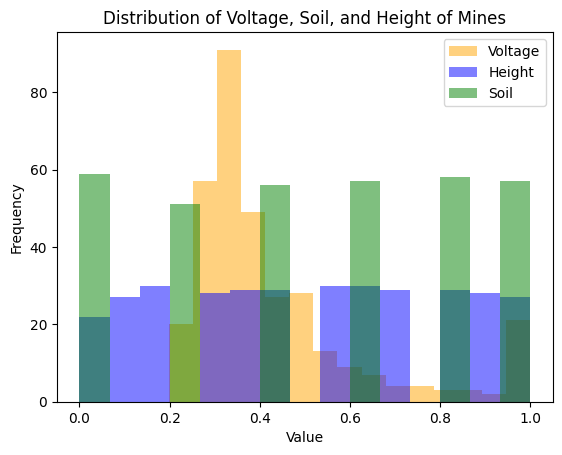

In [60]:
# Question 2
# Part 1

#import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from matplotlib import pyplot as plt

#load csv into mines variable
mines = pd.read_csv("land_mines.csv")

#summarize type variable using value_counts()
m_type = mines["mine_type"].value_counts()

#obtain info on numerical variables using describe()
soil = mines["soil"].describe()
volt = mines["voltage"].describe()
height = mines["height"].describe()

#print each summarization and amount of missing values
print(m_type, "\nMissing Values: " + str(mines["mine_type"].isna().sum())+ "\n")
print(soil, "\nMissing Values: " + str(mines["soil"].isna().sum()) + "\n")
print(volt, "\nMissing Values: " + str(mines["voltage"].isna().sum()) + "\n")
print(height, "\nMissing Values: " + str(mines["height"].isna().sum()) + "\n")

#create overlapping histograms of numerical variables to compare distributions
plt.hist(mines["voltage"], bins=15, alpha=0.5, color="orange", label="Voltage")
plt.hist(mines["height"], bins=15, alpha=0.5, color='blue', label="Height")
plt.hist(mines["soil"], bins=15, alpha=0.5, color="green", label="Soil")
plt.title("Distribution of Voltage, Soil, and Height of Mines")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [61]:
# Question 2
# Part 2

#Define x and y values based on above description, then split 50/50 with test_size=0.5
x_vals = mines[["voltage", "height", "soil"]]
y_vals = mines["mine_type"]
x_train, x_test, y_train, y_test = train_test_split(x_vals, y_vals, test_size=0.5, stratify=y_vals, random_state=26)

#We can observe from the above attribute summaries that they're all already between 0 and 1, so no scaling is necessary

In [ ]:
# Question 2
# Part 3

#utilize following algorithm to find k value that maximizes the accuracy of the test dataset (k_star): Returns 2
#use range of 1 to 10 for k candidates to ensure small dataset isn't underfit

k_vals = np.arange(1, 11)
test_acc = []
for k in k_vals:
    k_candidate = KNeighborsClassifier(n_neighbors=int(k))
    k_candidate.fit(x_train, y_train)
    test_hat = k_candidate.predict(x_test)
    test_acc.append(accuracy_score(y_test, test_hat))
k_star = int(k_vals[np.argmax(test_acc)])
print(f"Optimal k-value = {k_star}")

#create the kNN classifier utilizing the k_star value for k, generating predicted values from test data
model = KNeighborsClassifier(n_neighbors=k_star).fit(x_train, y_train)
y_pred = model.predict(x_test)

Optimal k-value = 2
[0.38461538461538464, 0.39644970414201186, 0.35502958579881655, 0.31952662721893493, 0.33727810650887574, 0.33727810650887574, 0.34911242603550297, 0.39644970414201186, 0.3609467455621302, 0.3609467455621302]


As mentioned above, I used an algorithm to find the k-value that maximizes the accuracy score of the test dataset, utilizing only a small range of 1 to 10 for k-value candidates to avoid underfitting the model.

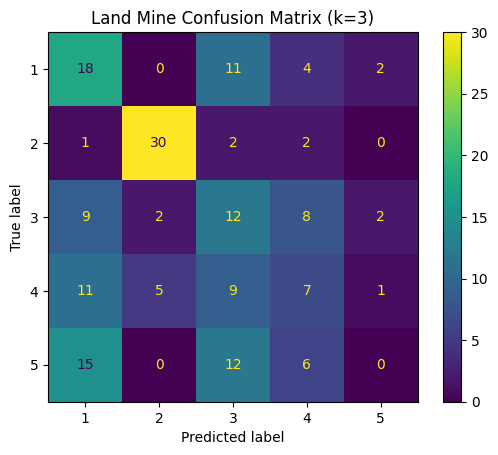

In [66]:
# Question 2
# Part 4
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])
display.plot()
plt.title("Land Mine Confusion Matrix (k=3)")
plt.show()

According to the confusion matrix, the model is accurate in many respects, predicting type 1 and 2 mines wiuthin phenomenal recall as evident by the low number of false negatives. On the other hand, the other three categories (3, 4, and 5) have serious flaws in accuracy with this model, with many of them being marked as being within the type 1 category and each having less than 15 (out of ~50 each) being predicted correctly.

### Question 2, Part 5:
With reference to the above confusion matrix, the only category of mine that can be consistently predicted correctly is type 2. This is because type 2 is the only category with a small number of false positive (observation is not type 2, but predicted as such) and false negative predictions (observation is type 2, but not predicted as such). Some categories, such as type 1, have too many false positives for the model to be applied unquestionably in practice. Other classes, like types 3, 4, and 5, produce generally inaccurate predictions since the model's predictions result in a high quantity of false positives and false negatives within these categories. Hence, my advice to anyone applying this model to a real-world minefield would be to trust the model when it predicts a mine is type 2, but do not take any other class prediction at face value and perform additional research to confirm the category of mine.

### *Reflection on AI assistance
In your own words without generative AI.

Utilizing the AI's suggestions, I was able to improve my descriptions of confusion matrices and overfitting/underfitting, create a visualization of overlapping histograms that increased the effectiveness of my EDA, and include stratification in the process of splitting my data to ensure an equal quantity of each mine type was included in each set. 

Each improvement was verified through the process of testing each suggestion in a copy of this notebook or performing additional research online and within the lecture slides.

Despite the improvements resulting from consulting AI, its suggestions were limited in a variety of ways. Firstly, many of them were overly technical and made little difference in the finished product. One example of this is when the AI criticized my use of the word "precision" to describe a class being predicted correctly, as such a term only referes to a low volume of false positives. Additionally, the AI carried a lack of focus, recommending changes outside of the bounds of each question.

Outside of these limitations, I don't have any major concerns, but perhaps it would be worth writing a clause in future prompts to only make suggestions based on the exact wording of each question.